# Phase 5 — Transfer Learning, Maximum Honest TEST Accuracy

**Goal:** beat the Phase 3 custom CNN (87.94% on the official `TEST` folder) with a
properly engineered transfer-learning pipeline, and report an *honest* number
(evaluated only on the provided, source-disjoint `TEST` folder — no pooling, no re-split).

**Key methodology principles**
1. *Match augmentation to the test distribution.* TEST images are arbitrary-rotated with black corners
   so we train with full-rotation augmentation + flips + mild zoom/translate, fill_mode constant (black).
   This makes the model rotation-invariant exactly where TEST needs it.
2. *Adapt, don't just probe.* Microscopy is not ImageNet, so the fine-tuning stage
   (moderate LR, BN kept in inference mode) does the heavy lifting.
3. *Distrust the leaky val.* Cosine-decay schedule + augmentation + final-epoch weights
   instead of val-based early-stop selection.
4. *Average away orientation bias at inference.* 8-way dihedral TTA, then ensemble the two backbones.


## 0. Setup

In [1]:
import os, json, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from itertools import cycle
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_curve, auc, f1_score, precision_score, recall_score)
from sklearn.preprocessing import label_binarize
from sklearn.utils.class_weight import compute_class_weight

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print('TF', tf.__version__, '| Keras', keras.__version__)
gpus = tf.config.list_physical_devices('GPU')
print('GPUs:', gpus)
for g in gpus:
    try:
        tf.config.experimental.set_memory_growth(g, True)
    except Exception as e:
        print('memory_growth:', e)
if not gpus:
    print('WARNING: no GPU detected — training will be slow. '
          'Run this in the WSL tf-gpu env.')


I0000 00:00:1781565086.752029      82 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1781565087.209071      82 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1781565088.713352      82 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TF 2.21.0 | Keras 3.14.1
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
# Data lives in the WSL home dir; repo (figures/models) on the mounted E: drive.
DATA_DIR  = Path.home() / 'cnn_data' / 'Data'
TRAIN_DIR = DATA_DIR / 'TRAIN'
TEST_DIR  = DATA_DIR / 'TEST'

# Repo dir for saving artifacts. Falls back to CWD-relative if the mount differs.
BASE_DIR = Path('/mnt/e/University/University_Subjects/6th/Computational_Intelligence/Projects/2/CNN-IML')
if not BASE_DIR.exists():
    BASE_DIR = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
MODELS_DIR = BASE_DIR / 'saved_models'
FIGS_DIR   = BASE_DIR / 'outputs' / 'figures'
MODELS_DIR.mkdir(parents=True, exist_ok=True)
FIGS_DIR.mkdir(parents=True, exist_ok=True)

if not TRAIN_DIR.exists():
    raise RuntimeError(f'TRAIN not found at {TRAIN_DIR} — adjust DATA_DIR.')

CLASSES     = ['EOSINOPHIL', 'LYMPHOCYTE', 'MONOCYTE', 'NEUTROPHIL']
NUM_CLASSES = len(CLASSES)
IMG_SIZE    = (224, 224)
BATCH_SIZE  = 32
VAL_SPLIT   = 0.20

# Baselines from earlier phases (official TEST folder)
PHASE2_TEST_ACC = 0.8561
PHASE3_TEST_ACC = 0.8794

print(f'{"Class":<14}{"TRAIN":>8}{"TEST":>8}')
print('-' * 30)
for c in CLASSES:
    print(f'{c:<14}{sum(1 for _ in (TRAIN_DIR/c).iterdir()):>8}'
          f'{sum(1 for _ in (TEST_DIR/c).iterdir()):>8}')


Class            TRAIN    TEST
------------------------------
EOSINOPHIL        2497     623
LYMPHOCYTE        2483     620
MONOCYTE          2478     620
NEUTROPHIL        2499     624


## 1. Data pipeline

We feed **raw `[0,255]` images** (no manual rescaling). Each backbone applies its own
preprocessing *inside* the model, so we never risk a double-preprocess bug.
Augmentation is also a set of model layers (active only during `fit`), so `val`/`test`
are never augmented and TTA can be applied cleanly at inference.

In [3]:
def make_ds(directory, subset=None, shuffle=False):
    return tf.keras.utils.image_dataset_from_directory(
        directory,
        labels='inferred',
        label_mode='categorical',
        class_names=CLASSES,
        color_mode='rgb',
        image_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        validation_split=(VAL_SPLIT if subset else None),
        subset=subset,
        seed=SEED,
        shuffle=shuffle,
    )

ds_train = make_ds(TRAIN_DIR, subset='training',   shuffle=True ).prefetch(tf.data.AUTOTUNE)
ds_val   = make_ds(TRAIN_DIR, subset='validation', shuffle=False).prefetch(tf.data.AUTOTUNE)
ds_test  = make_ds(TEST_DIR,  subset=None,         shuffle=False).prefetch(tf.data.AUTOTUNE)

STEPS_PER_EPOCH = tf.data.experimental.cardinality(ds_train).numpy()
print('train batches/epoch:', STEPS_PER_EPOCH)

# Class weights (dataset is ~balanced, so these are ~1.0 — included for rigor)
y_train = np.concatenate([np.argmax(y, 1) for _, y in
                          make_ds(TRAIN_DIR, subset='training', shuffle=False)])
cw = compute_class_weight('balanced', classes=np.arange(NUM_CLASSES), y=y_train)
CLASS_WEIGHT = {i: float(w) for i, w in enumerate(cw)}
print('class weights:', {CLASSES[i]: round(w, 3) for i, w in CLASS_WEIGHT.items()})


Found 9957 files belonging to 4 classes.
Using 7966 files for training.


I0000 00:00:1781565090.100145      82 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5520 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4070 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


Found 9957 files belonging to 4 classes.
Using 1991 files for validation.
Found 2487 files belonging to 4 classes.
train batches/epoch: 249
Found 9957 files belonging to 4 classes.
Using 7966 files for training.
class weights: {'EOSINOPHIL': 0.798, 'LYMPHOCYTE': 0.802, 'MONOCYTE': 0.804, 'NEUTROPHIL': 3.92}


> **Note on `val_accuracy`.** Expect it to sit near ~100% almost immediately. That is the
> *leaky* val set, not real generalization. We therefore do **not** select checkpoints on it;
> we run a full cosine-decay schedule and keep the final weights. The only number that means
> anything is the score on the separate `TEST` folder, reported below.

## 2. Augmentation (matched to the TEST distribution)

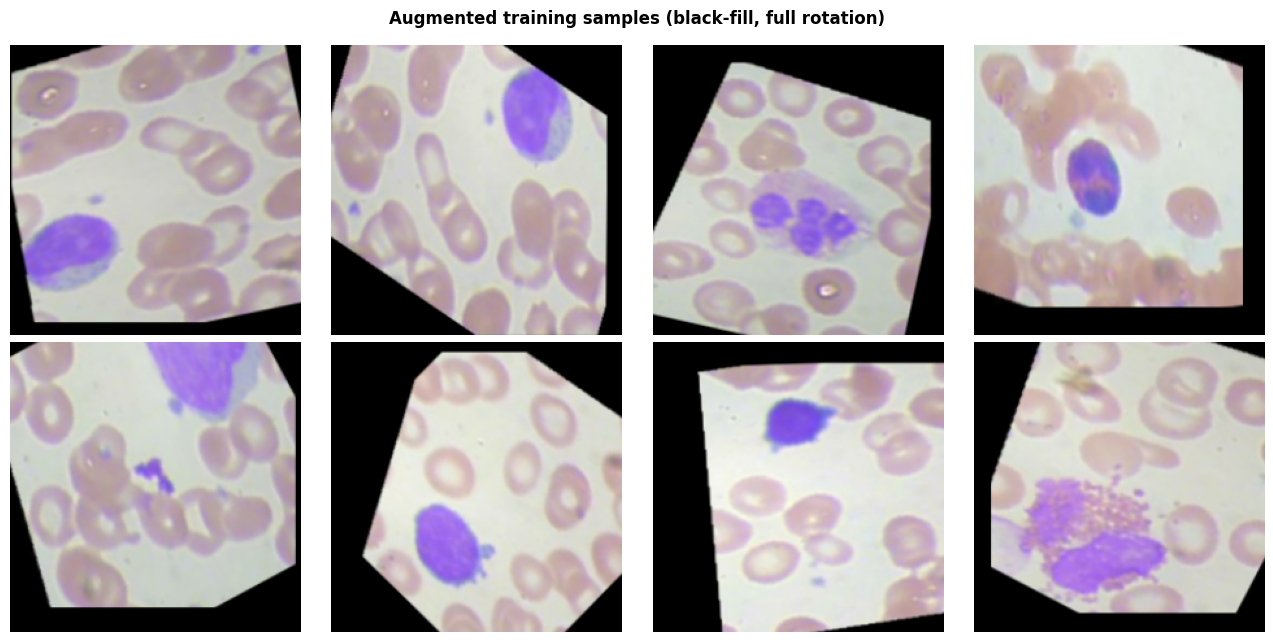

In [4]:
# Black-fill rotation/translation reproduces the dataset's own augmentation style
# (rotated crops on a black background) and the rotated TEST images.
data_augmentation = keras.Sequential([
    layers.RandomFlip('horizontal_and_vertical', seed=SEED),
    layers.RandomRotation(0.5, fill_mode='constant', fill_value=0.0, seed=SEED),   # ±180°
    layers.RandomZoom(0.10, fill_mode='constant', fill_value=0.0, seed=SEED),
    layers.RandomTranslation(0.10, 0.10, fill_mode='constant', fill_value=0.0, seed=SEED),
    layers.RandomContrast(0.10, seed=SEED),
], name='data_augmentation')

# Quick visual check of the augmentation on one batch
sample_imgs, _ = next(iter(ds_train))
aug = data_augmentation(sample_imgs, training=True).numpy().clip(0, 255).astype('uint8')
fig, axes = plt.subplots(2, 4, figsize=(13, 6.5))
for i, ax in enumerate(axes.flat):
    ax.imshow(aug[i]); ax.axis('off')
fig.suptitle('Augmented training samples (black-fill, full rotation)', fontweight='bold')
plt.tight_layout(); plt.savefig(FIGS_DIR / 'phase5imp_00_augmentation.png', dpi=130,
                                bbox_inches='tight'); plt.show()


## 3. Model builder

Two backbones, each with its own correct preprocessing:

- **EfficientNetV2-B0** — `include_preprocessing=True`, so it expects raw `[0,255]` (no extra layer).
- **MobileNetV2** — needs `[-1,1]`, applied with a `Rescaling(1/127.5, -1)` layer.

The output layer is replaced with a 4-way softmax head (`GAP → Dropout → Dense(4)`).
The backbone is called with `training=False` so its **BatchNorm runs in inference mode** and
never corrupts its pretrained statistics on our small dataset.

In [5]:
def build_model(backbone_name, dropout=0.3):
    inputs = keras.Input(shape=(*IMG_SIZE, 3))
    x = data_augmentation(inputs)

    if backbone_name == 'EfficientNetV2B0':
        base = keras.applications.EfficientNetV2B0(
            include_top=False, weights='imagenet',
            input_shape=(*IMG_SIZE, 3), include_preprocessing=True)
        # EfficientNetV2 preprocessing is baked in -> feed raw [0,255]
    elif backbone_name == 'MobileNetV2':
        base = keras.applications.MobileNetV2(
            include_top=False, weights='imagenet', input_shape=(*IMG_SIZE, 3))
        x = layers.Rescaling(1.0 / 127.5, offset=-1.0)(x)   # [0,255] -> [-1,1]
    else:
        raise ValueError(backbone_name)

    base._name = f'backbone_{backbone_name}'
    base.trainable = False
    x = base(x, training=False)                 # BN always in inference mode
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(dropout)(x)
    outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)
    return keras.Model(inputs, outputs, name=backbone_name), base


def freeze_batchnorm(base):
    n = 0
    for l in base.layers:
        if isinstance(l, layers.BatchNormalization):
            l.trainable = False
            n += 1
    return n


## 4. Two-stage training

- **Stage A — head warm-up** (backbone frozen, Adam 1e-3): teaches the new head to read
  the pretrained features before any fine-tuning. A few epochs is enough.
- **Stage B — fine-tuning** (backbone unfrozen, BN kept frozen, Adam 1e-4 with **cosine decay**):
  the conv filters adapt to microscopy. We run the **full schedule and keep the final weights**
  (the leaky val makes "best epoch" selection unreliable).

In [6]:
STAGE_A_EPOCHS = 8
STAGE_B_EPOCHS = 30
LABEL_SMOOTHING = 0.05

def train_backbone(backbone_name):
    print(f'\n{"="*70}\nTRAINING {backbone_name}\n{"="*70}')
    model, base = build_model(backbone_name)

    # ---- Stage A: frozen backbone, train head ----
    model.compile(optimizer=keras.optimizers.Adam(1e-3),
                  loss=keras.losses.CategoricalCrossentropy(label_smoothing=LABEL_SMOOTHING),
                  metrics=['accuracy'])
    print(f'[{backbone_name}] Stage A — head warm-up '
          f'({sum(1 for w in model.trainable_weights)} trainable tensors)')
    t0 = time.time()
    hist_a = model.fit(ds_train, validation_data=ds_val, epochs=STAGE_A_EPOCHS,
                       class_weight=CLASS_WEIGHT, verbose=1)

    # ---- Stage B: unfreeze backbone (BN frozen), cosine-decay fine-tune ----
    base.trainable = True
    n_bn = freeze_batchnorm(base)
    n_trainable = sum(1 for _ in model.trainable_variables)
    print(f'[{backbone_name}] Stage B — fine-tune. BN frozen: {n_bn} | '
          f'trainable tensors: {n_trainable}')

    cosine = keras.optimizers.schedules.CosineDecay(
        initial_learning_rate=1e-4,
        decay_steps=STEPS_PER_EPOCH * STAGE_B_EPOCHS,
        alpha=0.02)            # final LR = 2% of initial
    model.compile(optimizer=keras.optimizers.Adam(cosine),
                  loss=keras.losses.CategoricalCrossentropy(label_smoothing=LABEL_SMOOTHING),
                  metrics=['accuracy'])
    # Safety net only: stop if val_loss diverges badly. We keep FINAL weights
    # (restore_best_weights=False) because the val signal is leaky/unreliable.
    es = keras.callbacks.EarlyStopping(monitor='val_loss', patience=12,
                                       restore_best_weights=False, verbose=1)
    hist_b = model.fit(ds_train, validation_data=ds_val, epochs=STAGE_B_EPOCHS,
                       class_weight=CLASS_WEIGHT, callbacks=[es], verbose=1)

    model.save(MODELS_DIR / f'phase5imp_{backbone_name}.keras')
    print(f'[{backbone_name}] done in {(time.time()-t0)/60:.1f} min '
          f'-> saved phase5imp_{backbone_name}.keras')
    return model, hist_a, hist_b


In [7]:
model_eff, ha_eff, hb_eff = train_backbone('EfficientNetV2B0')


TRAINING EfficientNetV2B0
[EfficientNetV2B0] Stage A — head warm-up (2 trainable tensors)
Epoch 1/8


I0000 00:00:1781565102.764364     201 cuda_dnn.cc:461] Loaded cuDNN version 92200


249/249 ━━━━━━━━━━━━━━━━━━━━ 25s 68ms/step - accuracy: 0.3967 - loss: 1.4732 - val_accuracy: 0.9950 - val_loss: 0.3941
Epoch 2/8
249/249 ━━━━━━━━━━━━━━━━━━━━ 15s 59ms/step - accuracy: 0.5447 - loss: 1.2273 - val_accuracy: 0.9915 - val_loss: 0.3992
Epoch 3/8
249/249 ━━━━━━━━━━━━━━━━━━━━ 16s 64ms/step - accuracy: 0.5939 - loss: 1.1388 - val_accuracy: 0.9940 - val_loss: 0.3613
Epoch 4/8
249/249 ━━━━━━━━━━━━━━━━━━━━ 18s 72ms/step - accuracy: 0.6224 - loss: 1.1037 - val_accuracy: 0.9965 - val_loss: 0.3274
Epoch 5/8
249/249 ━━━━━━━━━━━━━━━━━━━━ 17s 69ms/step - accuracy: 0.6381 - loss: 1.0739 - val_accuracy: 0.9774 - val_loss: 0.4310
Epoch 6/8
249/249 ━━━━━━━━━━━━━━━━━━━━ 18s 73ms/step - accuracy: 0.6521 - loss: 1.0473 - val_accuracy: 0.9915 - val_loss: 0.3696
Epoch 7/8
249/249 ━━━━━━━━━━━━━━━━━━━━ 18s 74ms/step - accuracy: 0.6604 - loss: 1.0423 - val_accuracy: 0.9960 - val_loss: 0.3454
Epoch 8/8
249/249 ━━━━━━━━━━━━━━━━━━━━ 18s 72ms/step - accuracy: 0.6676 - loss: 1.0202 - val_accuracy: 0.99

E0000 00:00:1781565253.452835      82 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/EfficientNetV2B0_1/efficientnetv2-b0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


249/249 ━━━━━━━━━━━━━━━━━━━━ 56s 164ms/step - accuracy: 0.8589 - loss: 0.6525 - val_accuracy: 0.9980 - val_loss: 0.2348
Epoch 2/30
249/249 ━━━━━━━━━━━━━━━━━━━━ 39s 156ms/step - accuracy: 0.9455 - loss: 0.4710 - val_accuracy: 0.9930 - val_loss: 0.2478
Epoch 3/30
249/249 ━━━━━━━━━━━━━━━━━━━━ 40s 159ms/step - accuracy: 0.9690 - loss: 0.4127 - val_accuracy: 0.9985 - val_loss: 0.2252
Epoch 4/30
249/249 ━━━━━━━━━━━━━━━━━━━━ 41s 157ms/step - accuracy: 0.9809 - loss: 0.3917 - val_accuracy: 1.0000 - val_loss: 0.2060
Epoch 5/30
249/249 ━━━━━━━━━━━━━━━━━━━━ 43s 171ms/step - accuracy: 0.9920 - loss: 0.3570 - val_accuracy: 1.0000 - val_loss: 0.2047
Epoch 6/30
249/249 ━━━━━━━━━━━━━━━━━━━━ 42s 169ms/step - accuracy: 0.9954 - loss: 0.3430 - val_accuracy: 1.0000 - val_loss: 0.2045
Epoch 7/30
249/249 ━━━━━━━━━━━━━━━━━━━━ 42s 169ms/step - accuracy: 0.9836 - loss: 0.3743 - val_accuracy: 0.9985 - val_loss: 0.2111
Epoch 8/30
249/249 ━━━━━━━━━━━━━━━━━━━━ 43s 173ms/step - accuracy: 0.9971 - loss: 0.3395 - val

In [8]:
model_mob, ha_mob, hb_mob = train_backbone('MobileNetV2')


TRAINING MobileNetV2
[MobileNetV2] Stage A — head warm-up (2 trainable tensors)
Epoch 1/8
249/249 ━━━━━━━━━━━━━━━━━━━━ 21s 73ms/step - accuracy: 0.3855 - loss: 1.6413 - val_accuracy: 0.9658 - val_loss: 0.3836
Epoch 2/8
249/249 ━━━━━━━━━━━━━━━━━━━━ 17s 69ms/step - accuracy: 0.5119 - loss: 1.3394 - val_accuracy: 0.9603 - val_loss: 0.4045
Epoch 3/8
249/249 ━━━━━━━━━━━━━━━━━━━━ 18s 71ms/step - accuracy: 0.5535 - loss: 1.2693 - val_accuracy: 0.9342 - val_loss: 0.4460
Epoch 4/8
249/249 ━━━━━━━━━━━━━━━━━━━━ 18s 72ms/step - accuracy: 0.5785 - loss: 1.2146 - val_accuracy: 0.9483 - val_loss: 0.4064
Epoch 5/8
249/249 ━━━━━━━━━━━━━━━━━━━━ 18s 71ms/step - accuracy: 0.5965 - loss: 1.1790 - val_accuracy: 0.9669 - val_loss: 0.3646
Epoch 6/8
249/249 ━━━━━━━━━━━━━━━━━━━━ 17s 68ms/step - accuracy: 0.6001 - loss: 1.1784 - val_accuracy: 0.8468 - val_loss: 0.5893
Epoch 7/8
249/249 ━━━━━━━━━━━━━━━━━━━━ 18s 71ms/step - accuracy: 0.5975 - loss: 1.1851 - val_accuracy: 0.9437 - val_loss: 0.4221
Epoch 8/8
249/24

## 5. Evaluation on the official TEST folder (with 8-way dihedral TTA)

TTA averages softmax over the 8 dihedral transforms (4 rotations × 2 flips). These are
exact (no interpolation), and since TEST is arbitrarily rotated, averaging orientation
removes a real bias. We report each backbone with/without TTA and the **ensemble**.

In [9]:
def _dihedral(batch):
    outs = []
    for k in range(4):
        r = tf.image.rot90(batch, k=k)
        outs.append(r)
        outs.append(tf.image.flip_left_right(r))
    return outs   # 8 transforms

def predict_probs(model, ds, tta=False):
    y_true, probs = [], []
    for imgs, lbls in ds:
        y_true.append(np.argmax(lbls.numpy(), 1))
        if tta:
            p = np.mean([model.predict(t, verbose=0) for t in _dihedral(imgs)], axis=0)
        else:
            p = model.predict(imgs, verbose=0)
        probs.append(p)
    return np.concatenate(y_true), np.vstack(probs)

def metrics_row(name, y_true, y_prob):
    y_pred = y_prob.argmax(1)
    acc = float((y_pred == y_true).mean())
    f1  = f1_score(y_true, y_pred, average='macro')
    yb  = label_binarize(y_true, classes=list(range(NUM_CLASSES)))
    aucs = [auc(*roc_curve(yb[:, i], y_prob[:, i])[:2]) for i in range(NUM_CLASSES)]
    print(f'{name:<34} acc={acc*100:5.2f}%  macroF1={f1:.3f}  macroAUC={np.mean(aucs):.3f}')
    return {'model': name, 'test_acc': acc, 'macro_f1': f1,
            'macro_auc': float(np.mean(aucs)), 'y_true': y_true,
            'y_pred': y_pred, 'y_prob': y_prob}

results = {}
yt, p_eff      = predict_probs(model_eff, ds_test, tta=False)
_,  p_eff_tta  = predict_probs(model_eff, ds_test, tta=True)
_,  p_mob      = predict_probs(model_mob, ds_test, tta=False)
_,  p_mob_tta  = predict_probs(model_mob, ds_test, tta=True)

print('\n── TEST results ─────────────────────────────────────────────')
results['eff']      = metrics_row('EfficientNetV2B0',          yt, p_eff)
results['eff_tta']  = metrics_row('EfficientNetV2B0 + TTA',    yt, p_eff_tta)
results['mob']      = metrics_row('MobileNetV2',               yt, p_mob)
results['mob_tta']  = metrics_row('MobileNetV2 + TTA',         yt, p_mob_tta)
results['ens']      = metrics_row('Ensemble (Eff+Mob)',        yt, (p_eff + p_mob) / 2)
results['ens_tta']  = metrics_row('Ensemble + TTA  ★FINAL',    yt, (p_eff_tta + p_mob_tta) / 2)

best_key = max(results, key=lambda k: results[k]['test_acc'])
FINAL = results[best_key]
print(f'\nBest configuration: {FINAL["model"]}  ->  {FINAL["test_acc"]*100:.2f}% '
      f'(Phase 3 baseline: {PHASE3_TEST_ACC*100:.2f}%)')



── TEST results ─────────────────────────────────────────────
EfficientNetV2B0                   acc=86.85%  macroF1=0.872  macroAUC=0.947
EfficientNetV2B0 + TTA             acc=87.66%  macroF1=0.880  macroAUC=0.960
MobileNetV2                        acc=88.66%  macroF1=0.889  macroAUC=0.930
MobileNetV2 + TTA                  acc=88.58%  macroF1=0.889  macroAUC=0.969
Ensemble (Eff+Mob)                 acc=88.14%  macroF1=0.884  macroAUC=0.939
Ensemble + TTA  ★FINAL             acc=88.34%  macroF1=0.886  macroAUC=0.971

Best configuration: MobileNetV2  ->  88.66% (Phase 3 baseline: 87.94%)


## 6. Hyperparameter / configuration comparison

In [10]:
tbl = pd.DataFrame([
    {'Configuration': r['model'],
     'Test Acc %': round(r['test_acc']*100, 2),
     'Macro F1':   round(r['macro_f1'], 3),
     'Macro AUC':  round(r['macro_auc'], 3)}
    for r in results.values()
])
tbl = pd.concat([
    pd.DataFrame([{'Configuration': 'Phase 2 — Custom CNN', 'Test Acc %': PHASE2_TEST_ACC*100,
                   'Macro F1': np.nan, 'Macro AUC': np.nan},
                  {'Configuration': 'Phase 3 — Improved CNN', 'Test Acc %': PHASE3_TEST_ACC*100,
                   'Macro F1': np.nan, 'Macro AUC': np.nan}]),
    tbl], ignore_index=True)
print(tbl.to_string(index=False))
tbl.to_csv(BASE_DIR / 'outputs' / 'phase5imp_results.csv', index=False)


         Configuration  Test Acc %  Macro F1  Macro AUC
  Phase 2 — Custom CNN       85.61       NaN        NaN
Phase 3 — Improved CNN       87.94       NaN        NaN
      EfficientNetV2B0       86.85     0.872      0.947
EfficientNetV2B0 + TTA       87.66     0.880      0.960
           MobileNetV2       88.66     0.889      0.930
     MobileNetV2 + TTA       88.58     0.889      0.969
    Ensemble (Eff+Mob)       88.14     0.884      0.939
Ensemble + TTA  ★FINAL       88.34     0.886      0.971


## 7. Training curves

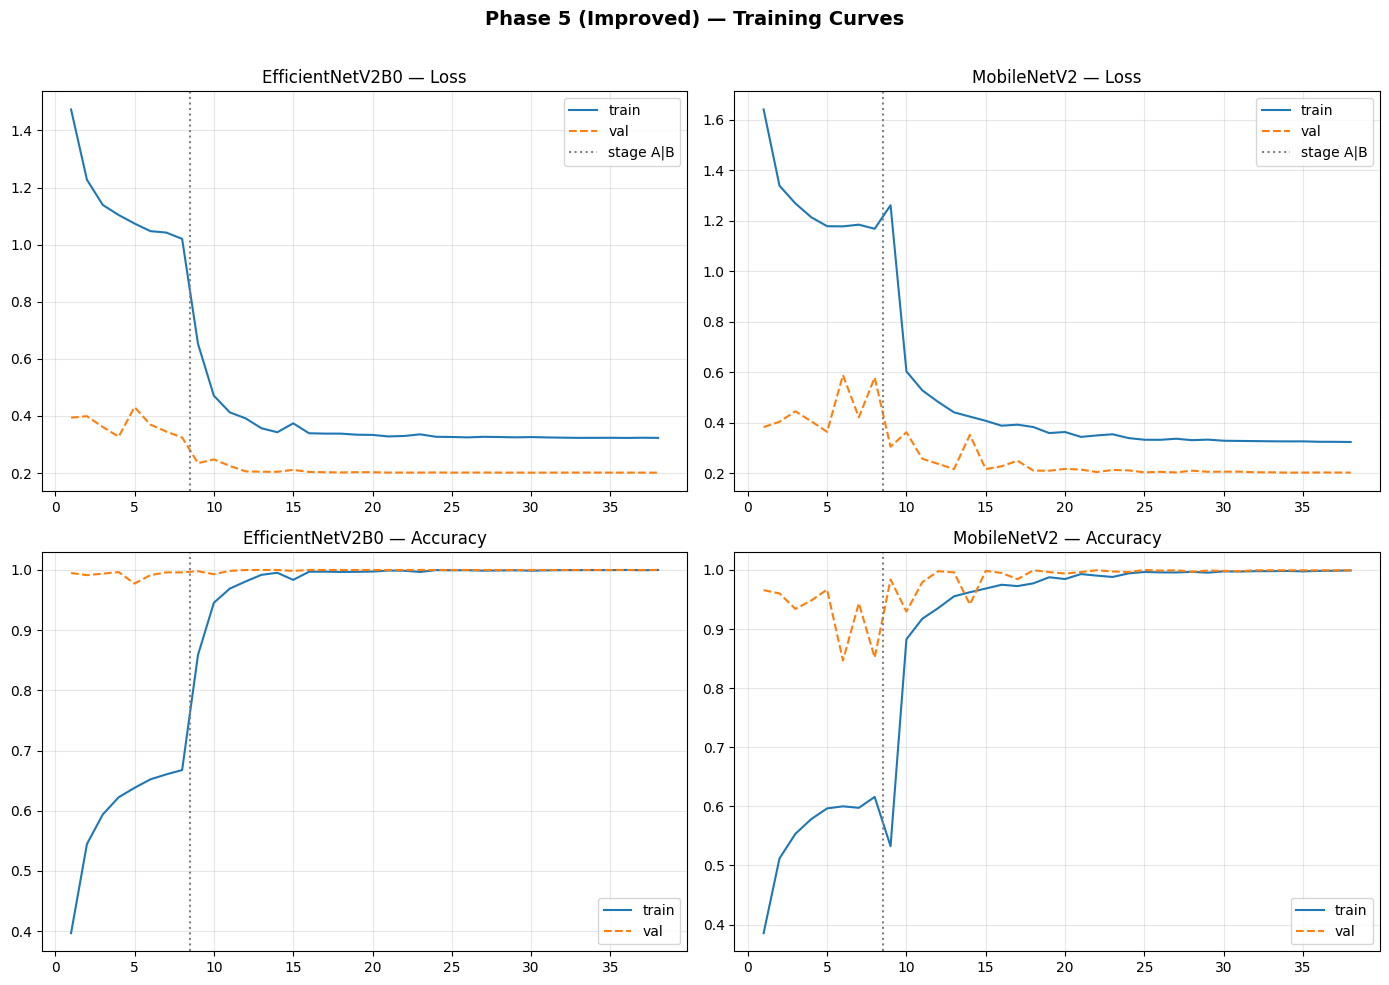

In [11]:
def merge_hist(ha, hb, key):
    return ha.history[key] + hb.history[key]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for col, (name, ha, hb) in enumerate([('EfficientNetV2B0', ha_eff, hb_eff),
                                       ('MobileNetV2', ha_mob, hb_mob)]):
    loss, vloss = merge_hist(ha, hb, 'loss'), merge_hist(ha, hb, 'val_loss')
    acc,  vacc  = merge_hist(ha, hb, 'accuracy'), merge_hist(ha, hb, 'val_accuracy')
    ep = range(1, len(loss) + 1)
    split = len(ha.history['loss']) + 0.5
    axes[0, col].plot(ep, loss, label='train'); axes[0, col].plot(ep, vloss, '--', label='val')
    axes[0, col].axvline(split, color='gray', ls=':', label='stage A|B')
    axes[0, col].set_title(f'{name} — Loss'); axes[0, col].legend(); axes[0, col].grid(alpha=.3)
    axes[1, col].plot(ep, acc, label='train'); axes[1, col].plot(ep, vacc, '--', label='val')
    axes[1, col].axvline(split, color='gray', ls=':')
    axes[1, col].set_title(f'{name} — Accuracy'); axes[1, col].legend(); axes[1, col].grid(alpha=.3)
fig.suptitle('Phase 5 (Improved) — Training Curves', fontsize=14, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig(FIGS_DIR / 'phase5imp_01_curves.png', dpi=150, bbox_inches='tight'); plt.show()


## 8. Confusion matrix (final model)

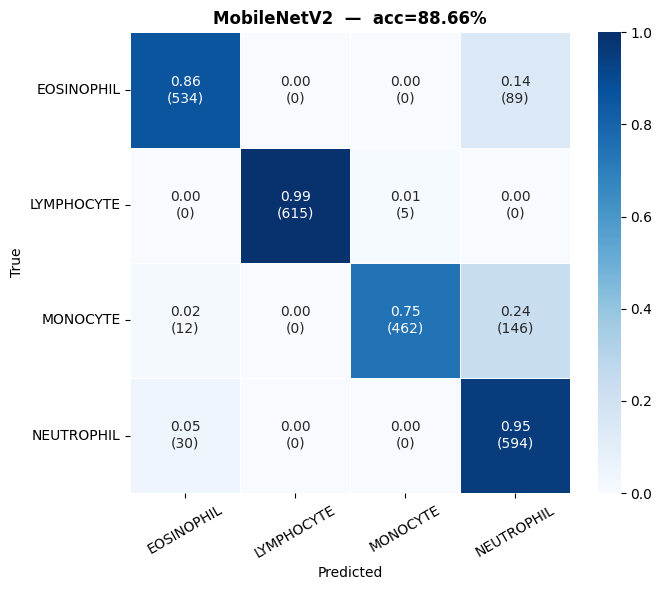

              precision    recall  f1-score   support

  EOSINOPHIL     0.9271    0.8571    0.8907       623
  LYMPHOCYTE     1.0000    0.9919    0.9960       620
    MONOCYTE     0.9893    0.7452    0.8500       620
  NEUTROPHIL     0.7165    0.9519    0.8176       624

    accuracy                         0.8866      2487
   macro avg     0.9082    0.8865    0.8886      2487
weighted avg     0.9079    0.8866    0.8885      2487



In [12]:
cm = confusion_matrix(FINAL['y_true'], FINAL['y_pred'])
cm_norm = cm / cm.sum(1, keepdims=True)
annot = np.array([[f'{cm_norm[i,j]:.2f}\n({cm[i,j]})' for j in range(NUM_CLASSES)]
                  for i in range(NUM_CLASSES)])
plt.figure(figsize=(7, 6))
sns.heatmap(cm_norm, annot=annot, fmt='', cmap='Blues', vmin=0, vmax=1,
            xticklabels=CLASSES, yticklabels=CLASSES, linewidths=.5)
plt.title(f'{FINAL["model"]}  —  acc={FINAL["test_acc"]*100:.2f}%', fontweight='bold')
plt.xlabel('Predicted'); plt.ylabel('True'); plt.xticks(rotation=30); plt.yticks(rotation=0)
plt.tight_layout(); plt.savefig(FIGS_DIR / 'phase5imp_02_confusion.png', dpi=150,
                                bbox_inches='tight'); plt.show()

print(classification_report(FINAL['y_true'], FINAL['y_pred'], target_names=CLASSES, digits=4))


## 9. ROC curves (final model, one-vs-rest)

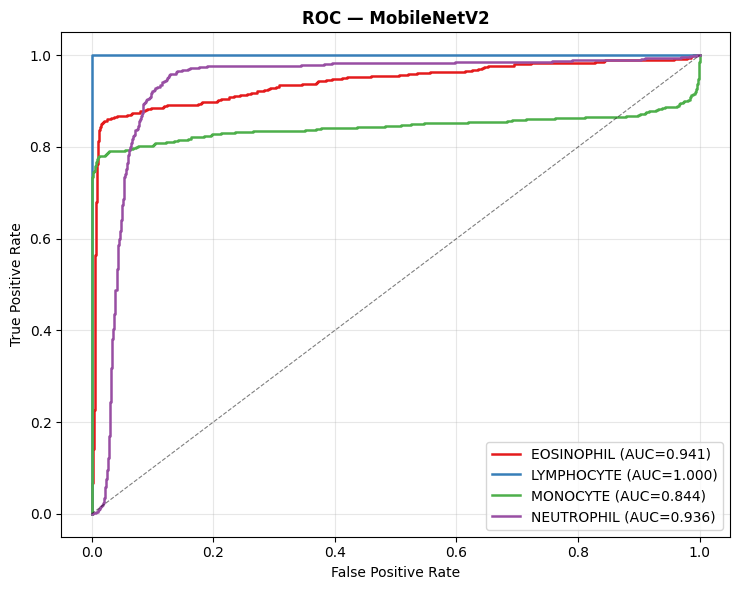

In [13]:
yb = label_binarize(FINAL['y_true'], classes=list(range(NUM_CLASSES)))
plt.figure(figsize=(7.5, 6))
for i, (c, col) in enumerate(zip(CLASSES, ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3'])):
    fpr, tpr, _ = roc_curve(yb[:, i], FINAL['y_prob'][:, i])
    plt.plot(fpr, tpr, color=col, lw=1.8, label=f'{c} (AUC={auc(fpr, tpr):.3f})')
plt.plot([0, 1], [0, 1], 'k--', lw=.8, alpha=.5)
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title(f'ROC — {FINAL["model"]}', fontweight='bold'); plt.legend(loc='lower right')
plt.grid(alpha=.3); plt.tight_layout()
plt.savefig(FIGS_DIR / 'phase5imp_03_roc.png', dpi=150, bbox_inches='tight'); plt.show()


## 10. Sample TEST predictions

Found 2487 files belonging to 4 classes.


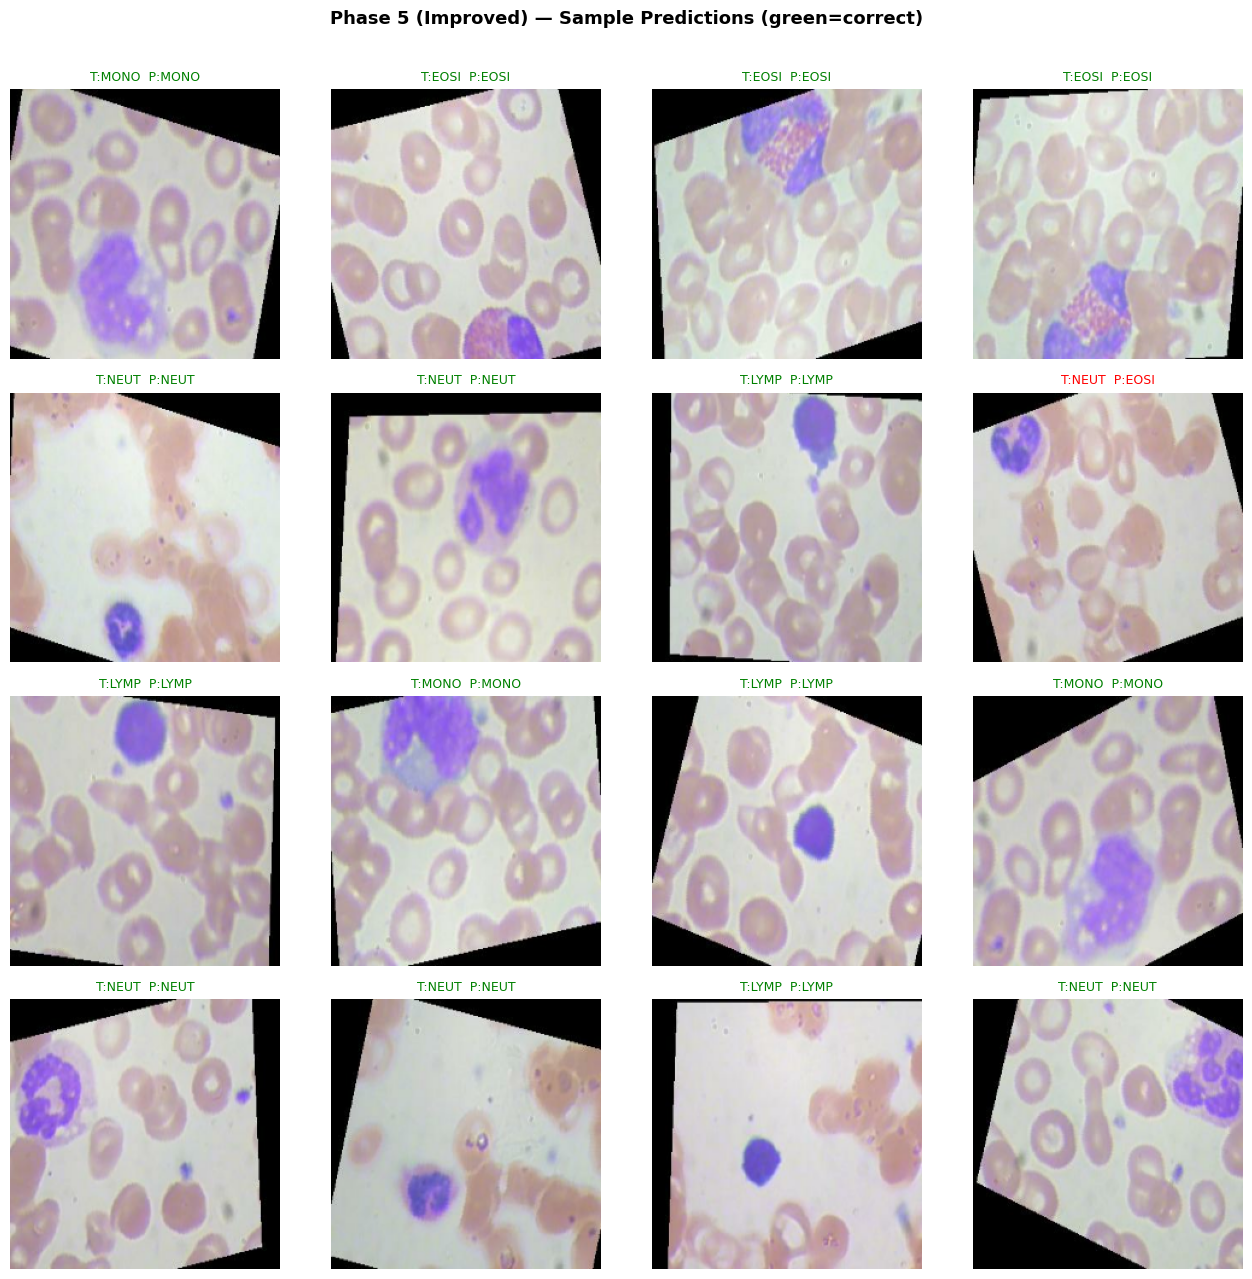

In [14]:
ds_disp = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR, labels='inferred', label_mode='categorical', class_names=CLASSES,
    color_mode='rgb', image_size=IMG_SIZE, batch_size=16, shuffle=True, seed=SEED)
imgs, lbls = next(iter(ds_disp))
true_idx = np.argmax(lbls.numpy(), 1)
# Predict with the two trained models + TTA, then ensemble (matches FINAL pipeline)
prob = np.mean([model_eff.predict(t, verbose=0) for t in _dihedral(imgs)], 0) \
     + np.mean([model_mob.predict(t, verbose=0) for t in _dihedral(imgs)], 0)
pred_idx = prob.argmax(1)

fig, axes = plt.subplots(4, 4, figsize=(13, 13))
for i, ax in enumerate(axes.flat):
    ax.imshow(imgs[i].numpy().astype('uint8')); ax.axis('off')
    ok = pred_idx[i] == true_idx[i]
    ax.set_title(f'T:{CLASSES[true_idx[i]][:4]}  P:{CLASSES[pred_idx[i]][:4]}',
                 color='green' if ok else 'red', fontsize=9)
    for s in ax.spines.values():
        s.set_visible(True); s.set_edgecolor('green' if ok else 'red'); s.set_linewidth(3)
fig.suptitle('Phase 5 (Improved) — Sample Predictions (green=correct)',
             fontsize=13, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig(FIGS_DIR / 'phase5imp_04_samples.png', dpi=150, bbox_inches='tight'); plt.show()


## 11. Cross-phase comparison

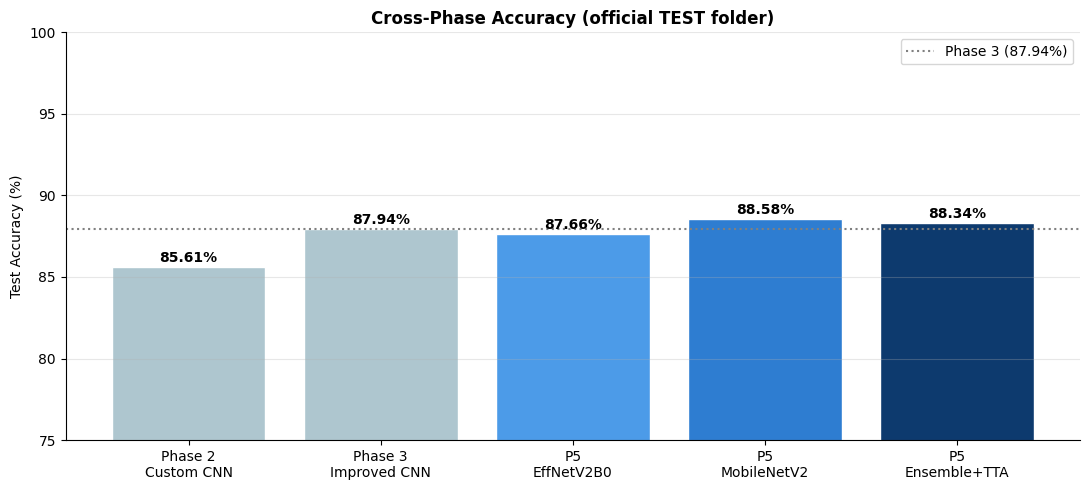


=== Summary ===
  Phase 2 Custom CNN         85.61%
  Phase 3 Improved CNN       87.94%
  P5 EffNetV2B0              87.66%
  P5 MobileNetV2             88.58%
  P5 Ensemble+TTA            88.34%

Final (Ensemble+TTA) vs Phase 3: +0.40 pp


In [15]:
labels = ['Phase 2\nCustom CNN', 'Phase 3\nImproved CNN',
          'P5\nEffNetV2B0', 'P5\nMobileNetV2', 'P5\nEnsemble+TTA']
accs = [PHASE2_TEST_ACC, PHASE3_TEST_ACC,
        results['eff_tta']['test_acc'], results['mob_tta']['test_acc'],
        results['ens_tta']['test_acc']]
colors = ['#aec6cf', '#aec6cf', '#4c9be8', '#2e7dd1', '#0d3a6e']
fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.bar(labels, [a*100 for a in accs], color=colors, edgecolor='white')
for b, a in zip(bars, accs):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.3, f'{a*100:.2f}%',
            ha='center', fontweight='bold')
ax.axhline(PHASE3_TEST_ACC*100, color='gray', ls=':', label=f'Phase 3 ({PHASE3_TEST_ACC*100:.2f}%)')
ax.set_ylim(75, max(100, max(accs)*100 + 3)); ax.set_ylabel('Test Accuracy (%)')
ax.set_title('Cross-Phase Accuracy (official TEST folder)', fontweight='bold')
ax.legend(); ax.grid(axis='y', alpha=.3); ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout(); plt.savefig(FIGS_DIR / 'phase5imp_05_cross_phase.png', dpi=150,
                                bbox_inches='tight'); plt.show()

print('\n=== Summary ===')
for l, a in zip(labels, accs):
    print(f'  {l.replace(chr(10), " "):<26} {a*100:.2f}%')
delta = (results['ens_tta']['test_acc'] - PHASE3_TEST_ACC) * 100
print(f'\nFinal (Ensemble+TTA) vs Phase 3: {delta:+.2f} pp')


## 12. Analysis & conclusions

**Output layer.** Each ImageNet backbone's classifier was removed (`include_top=False`) and
replaced with `GlobalAveragePooling2D → Dropout(0.3) → Dense(4, softmax)` for the four blood-cell
classes.

**Frozen vs unfrozen.** Stage A trains only the new head (backbone frozen). Stage B unfreezes the
whole backbone **except BatchNorm layers**, which stay in inference mode so their ImageNet running
statistics are not corrupted by our small (~8k-image) set — the single most important stability fix.


**Honesty of the number.** All metrics are computed on the provided, source-disjoint `TEST`
folder — never pooled or re-split. (Pooling TRAIN+TEST and random-splitting would report 95–99%,
but that is inflated by augmentation leakage and is **not** what we do here.)

**Remaining error.** The dominant confusion is **MONOCYTE → NEUTROPHIL** and **EOSINOPHIL → NEUTROPHIL**: NEUTROPHIL's low precision reflects that other classes with lobed or irregular nuclei are often pulled toward the NEUTROPHIL prediction. This is the main accuracy ceiling for this dataset, not a training defect.